In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy.stats import wilcoxon

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "1257933019" 
# tab_gid = '908803302'
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"]).iloc[:20, :]
df

,Model,Compression,BLEU
0,pythia-70M,Original,42.00
1,pythia-70M,8-bit,41.39
2,pythia-70M,4-bit,39.21
3,pythia-70M,dyn,35.99
4,pythia-160M,Original,42.49
5,pythia-160M,8-bit,42.31
6,pythia-160M,4-bit,40.60
7,pythia-160M,dyn,38.07
8,pythia-410M,Original,43.51
9,pythia-410M,8-bit,43.61


/var/folders/w8/v70q6cks3tndqf3zsc_g7y080000gn/T/ipykernel_43176/3757557188.py:12: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Compression"] = df["Compression"].replace({"Original": "Original (32-bit)", "8-bit": "Static (8-bit)", "dyn": "Dynamic (8-bit)"})


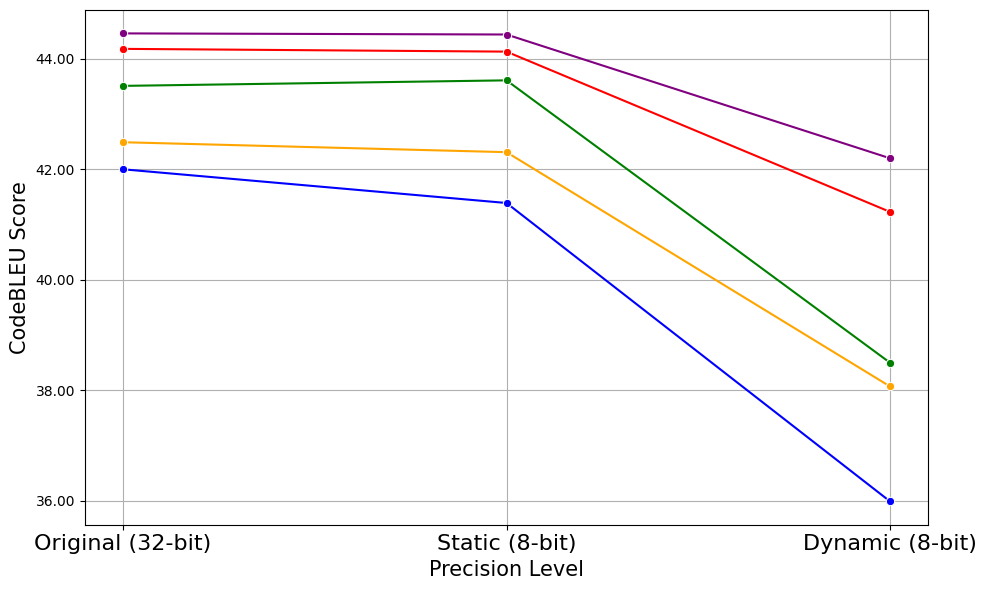

In [17]:
model_colors = {
    "pythia-70M": "blue",
    "pythia-160M": "orange",
    "pythia-410M": "green",
    "pythia-1B": "red",
    "pythia-1.4B": "purple"
}
compression_order = ["Original", "8-bit", "dyn"]
df["Compression"] = pd.Categorical(df["Compression"], categories=compression_order, ordered=True)

# x axis labels names rename
df["Compression"] = df["Compression"].replace({"Original": "Original (32-bit)", "8-bit": "Static (8-bit)", "dyn": "Dynamic (8-bit)"})

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Compression", y="BLEU", hue="Model", marker="o", palette=model_colors, legend=False)

plt.ylabel("CodeBLEU Score", fontsize=15)
plt.xlabel("Precision Level", fontsize=15)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
plt.xticks(fontsize=16)

plt.grid(True)
plt.tight_layout()
plt.savefig("./output/prelim-1.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
def check_significance(df, col1, col2):
    stat, p_value = wilcoxon(df[col1], df[col2], alternative='greater')
    if p_value < 0.05:
        print(f"({col1} vs {col2}): {stat}, p-value: {p_value} \033[92mThe difference is statistically significant.\033[0m")
    else:
        print(f"({col1} vs {col2}): {stat}, p-value: {p_value} \033[91mThe difference is NOT statistically significant.\033[0m")

In [21]:
limit = 20 #15 39
df0 = pd.read_csv(full_url, skiprows=2, usecols=["Model", "Compression", "BLEU"]).iloc[:limit, :]
df1 = df0.pivot(index="Model", columns="Compression", values="BLEU")
df = df1.reset_index()
print(df.shape)
check_significance(df, "Original", "8-bit")
check_significance(df, "Original", "dyn")

(5, 5)
(Original vs 8-bit): 12.0, p-value: 0.15625 The difference is NOT statistically significant.
(Original vs dyn): 15.0, p-value: 0.03125 The difference is statistically significant.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter

# Load CSV file
sheet_id = "1tEf8J1kbGZEFTOkoYqIjsdE3PkqBA9bX4MdNfMoLhjQ"
tab_gid = "1257933019"
# tab_gid = "1990888583" 
limit = 20
leftCol = "ROC_AUC"
full_url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={tab_gid}"
df = pd.read_csv(full_url, skiprows=2, usecols=['Model', 'Compression', leftCol, 'BLEU']).iloc[:limit, :]
df

,Model,Compression,BLEU,ROC_AUC
0,pythia-70M,Original,42.00,64.55
1,pythia-70M,8-bit,41.39,64.53
2,pythia-70M,4-bit,39.21,63.36
3,pythia-70M,dyn,35.99,56.73
4,pythia-160M,Original,42.49,65.70
5,pythia-160M,8-bit,42.31,65.66
6,pythia-160M,4-bit,40.60,64.50
7,pythia-160M,dyn,38.07,55.04
8,pythia-410M,Original,43.51,67.41
9,pythia-410M,8-bit,43.61,67.40


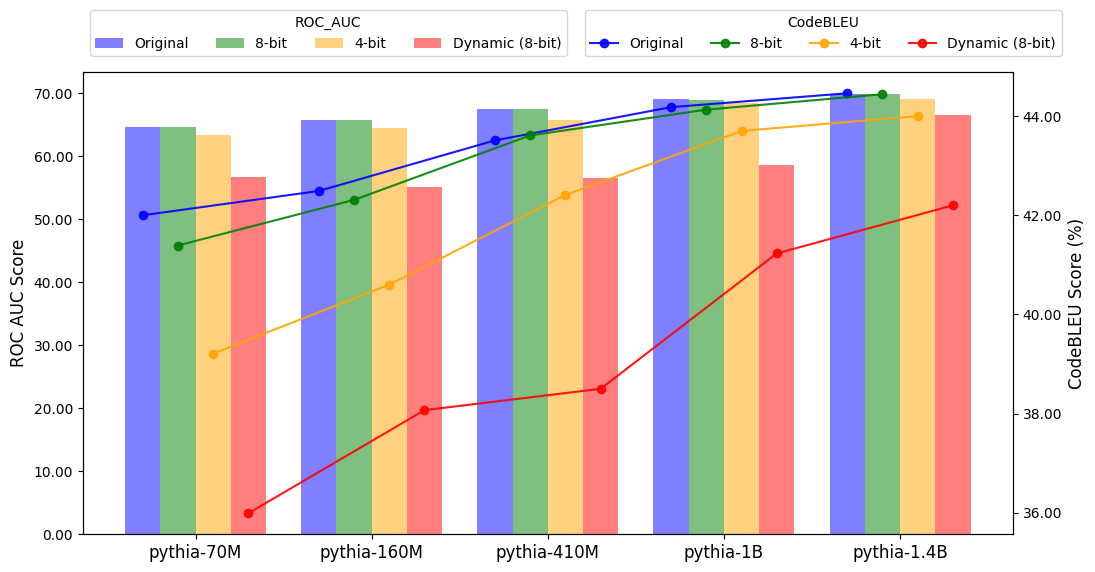

In [64]:

# Extract unique model names
models = df["Model"].unique()
compressions = df["Compression"].unique()
# Define bar width and colors
bar_width = 0.2
colors = ["blue", "green", "orange", "red"]

x = np.arange(len(models))  # X-axis positions

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot bar chart for model sizes
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax1.bar(x + i * bar_width, subset[leftCol], width=bar_width, label=f"{comp}", alpha=0.5, color=colors[i])

ax1.set_ylabel("ROC AUC Score", fontsize=12)
ax1.set_xticks(x + bar_width * 1.5)
ax1.set_xticklabels(models, rotation=0, fontsize=12)
ax1.legend(loc='upper left', bbox_to_anchor=(0, 1.15), title="ROC_AUC", ncol=len(ax1.get_legend_handles_labels()[0]))
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))
ax1.get_legend().get_texts()[3].set_text("Dynamic (8-bit)")

# Second y-axis for performance scores
ax2 = ax1.twinx()
# Plot line chart for performance
for i, comp in enumerate(compressions):
    subset = df[df["Compression"] == comp]
    ax2.plot(x + i * bar_width, subset["BLEU"], marker="o", linestyle="-", label=f"{comp}", color=colors[i], alpha=0.9)

ax2.set_ylabel("CodeBLEU Score (%)", fontsize=12)
ax2.legend(
    loc='upper right',
    bbox_to_anchor=(1.06, 1.15),
    title="CodeBLEU",
    ncol=len(ax2.get_legend_handles_labels()[0])
)
ax2.get_legend().get_texts()[3].set_text("Dynamic (8-bit)")

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.2f}'))

plt.savefig(f"./output/MIAvsTask.png", dpi=300, bbox_inches="tight")
plt.show()